In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

from datetime import datetime, timedelta
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    KnownTurnRate,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Munk, Constant, Linear, FlatBathymetry
from nereus.models.propagation import CylindricalAcousticPropagationModel, rtrsAcousticPropagationModel
from nereus.signal.anthropogenic import BroadbandShipSignal
from nereus.signal.ambient import ColouredNoise
from nereus.simulator import BroadbandPassiveSonarArraySimulator
from nereus.sigproc import DelayAndSumBeamformer, SteeringCalculator, MinimumVarianceDistortionlessResponseBeamformer
from nereus.detector import CFARDetector, PassiveSonarDetector, PeakDetector
from nereus.plotter import BearingsPlotter

seed = 1
print(f"seed: {seed}")
np.random.seed(seed)

def generate_random_maneuvers(total_duration_s, timestep_s, min_leg_duration_s=60, max_leg_duration_s=300, maneuver_prob=0.5):
    """Generate random sequence of straight/turn maneuvers. manoeuvrers
    
    Args:
        total_duration_s: Total simulation time in seconds
        timestep_s: Simulation timestep in seconds
        min_leg_duration_s: Minimum duration for each leg
        max_leg_duration_s: Maximum duration for each leg
        maneuver_prob: Probability of performing a turn maneuver at each leg
    
    Returns:
        maneuver_models: List of transition models (3D)
        maneuver_durations: List of timedelta durations for each leg
        maneuver_descriptions: List of string descriptions for logging
    """
    maneuver_models = []
    maneuver_durations = []
    maneuver_descriptions = []
    
    current_time = 0.0
    
    while current_time < total_duration_s - min_leg_duration_s:
        # Random leg duration (round to nearest timestep)
        leg_duration = np.random.uniform(min_leg_duration_s, max_leg_duration_s)
        leg_duration = round(leg_duration / timestep_s) * timestep_s
        leg_duration = min(leg_duration, total_duration_s - current_time)
        
        # Decide maneuver
        if np.random.rand() > maneuver_prob:
            # Straight leg
            model = CombinedLinearGaussianTransitionModel([
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0)
            ])
            description = f"Straight ({leg_duration:.0f}s)"
        else:
            # Random turn: -90° to +90° (negative = right turn, positive = left turn)
            turn_angle_deg = np.random.uniform(-90, 90)
            turn_rate_deg_per_s = 1.0  # Standard turn rate
            
            # Calculate actual turn duration based on angle
            turn_duration_s = abs(turn_angle_deg) / turn_rate_deg_per_s
            turn_duration_s = round(turn_duration_s / timestep_s) * timestep_s
            leg_duration = min(turn_duration_s, total_duration_s - current_time)
            
            turn_rate_rad = np.deg2rad(np.sign(turn_angle_deg) * turn_rate_deg_per_s)
            
            turning_2d = KnownTurnRate(
                turn_rate=turn_rate_rad,
                turn_noise_diff_coeffs=np.array([0.0, 0.0])
            )
            
            model = CombinedLinearGaussianTransitionModel([
                turning_2d,
                ConstantVelocity(0.0)  # Constant depth
            ])
            
            direction = "Left" if turn_angle_deg > 0 else "Right"
            description = f"{direction} Turn {abs(turn_angle_deg):.0f}° ({leg_duration:.0f}s)"
        
        maneuver_models.append(model)
        maneuver_durations.append(timedelta(seconds=leg_duration))
        maneuver_descriptions.append(description)
        
        current_time += leg_duration
    
    return maneuver_models, maneuver_durations, maneuver_descriptions

seed: 1


# SIMULATION PARAMETERS

In [50]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================

SIM_LENGTH = 900 # seconds
SIM_RATE = 5.0 # seconds

Xlim = [-15_000, 15_000]
Ylim = [-15_000, 15_000]

NUM_TARGETS = 2

SIM_PARAMS = {
    "start_time":datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval":timedelta(seconds=SIM_RATE),
    "num_steps":int(SIM_LENGTH / SIM_RATE),
}

total_duration_s = SIM_PARAMS["num_steps"] * SIM_PARAMS["time_interval"].total_seconds()
print(f"Total simulation duration: {total_duration_s} seconds")
print(f"Number of timesteps: {SIM_PARAMS['num_steps']}, Timestep interval: {SIM_PARAMS['time_interval'].total_seconds()} seconds")

SHIP_PARAMS = {
    "start_vector": np.array([0.0, 0.0, 0.0, 5.0, -5.0, 0.0]),
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 50,  
    "tow_cable_length": 100.0,
    "sensor_spacing": 0.5,
    "array_depth": -50.0,
}

TARGETS = []
TARGET_1_PARAMS = {
    "start_vector": np.array([1000.0, 5.0, 1000.0, 5.0, -5.0, 0.0]),
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
    "amplitudes_upa": 10 ** (np.array([90.0]) / 20),
    "frequencies_hz": [75.0],
    "phases_rad": [0.0],
    "tonal_bandwidth_hz": 2.0,
    "noise_amplitude_upa":10 ** (60 / 20),
    "noise_spectral_exponent":-1.0,
}
TARGETS.append(TARGET_1_PARAMS)
TARGET_2_PARAMS = {
    "start_vector": np.array([1000.0, 5.0, 3000.0, -5.0, -5.0, 0.0]), 
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
    "amplitudes_upa": 10 ** (np.array([100.0]) / 20),
    "frequencies_hz": [100.0],
    "phases_rad": [0.0],
    "tonal_bandwidth_hz": 2.0,
    "noise_amplitude_upa":10 ** (60 / 20),
    "noise_spectral_exponent":-1.0,
}
TARGETS.append(TARGET_2_PARAMS)

SIGNAL_PARAMS = {
    "duration_s": total_duration_s,
    "sampling_rate_hz": 500.0, 
    "frame_len": 500,
    "hop_factor": 2,
    "fade_in_ms": 1000.0,
}

AMBIENT_NOISE_PARAMS = {
    "amplitude_upa": 10 ** (45.0 / 20),  
    "spectral_exponent": -1,  
}

PROP_PARAMS = {
    # "ssp": Constant(speed=1500.0), 
    "ssp": Linear(surface_speed=1500.0, gradient=0.2),
    # "ssp": Munk(),
    "attenuation_factor": 0.5, 
    "bathymetry": FlatBathymetry(depth=-150.0),
    # "bathymetry": FlatBathymetry(depth=-5000.0),
    "step_m": 20.0,
    "azimuth_search_width": 2.0,
    "azimuth_resolution": 0.5,
    "elevation_range": (-25.0, 25.0),
    "elevation_resolution": 1.0,
}


BF_1_PARAMS = {
    "beamformer_type": "MVDR",
    "shading": None,    # shading is only for DAS, does nothing with MVDR
    # "shading": "blackman",
    "domain": "broadband_power",  # "time", "frequency", or "broadband_power" for DAS only
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 101), 
    "fmin": 70.0,
    "fmax": 105.0,
    # "fmin": None,
    # "fmax": None,
}
BF_2_PARAMS = {
    "beamformer_type": "MVDR",
    "shading": None,    # shading is only for DAS, does nothing with MVDR
    # "shading": "blackman",
    "domain": "broadband_power",  # "time", "frequency", or "broadband_power" for DAS only
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 101), 
    "fmin": 70.0,
    "fmax": 80.0,
    # "fmin": None,
    # "fmax": None,
}
BF_3_PARAMS = {
    "beamformer_type": "MVDR",
    "shading": None,    # shading is only for DAS, does nothing with MVDR
    # "shading": "blackman",
    "domain": "broadband_power",  # "time", "frequency", or "broadband_power" for DAS only
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 101), 
    "fmin": 95.0,
    "fmax": 105.0,
    # "fmin": None,
    # "fmax": None,
}
BF_PARAMS_LIST = [BF_1_PARAMS, BF_2_PARAMS, BF_3_PARAMS]

# Detection parameters
DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 2,
        "num_training_cells": 10,
        "threshold_factor": 2.1,  
    },
    "peak_detector": {
        "distance": 3,  
    }
}

Total simulation duration: 900.0 seconds
Number of timesteps: 180, Timestep interval: 5.0 seconds


# SETUP

In [51]:
# ============================================================================
# SETUP
# ============================================================================

# Generate random maneuvers for platform
print("Generating random platform maneuvers...")
maneuver_models, maneuver_durations, maneuver_descriptions = generate_random_maneuvers(
    total_duration_s=total_duration_s,
    timestep_s=SIM_PARAMS["time_interval"].total_seconds(),
    min_leg_duration_s=60,
    max_leg_duration_s=300,  
    maneuver_prob=0.25
)

# Create platform
initial_state = GroundTruthState(
    SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"]
)

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    # transition_models=[SHIP_PARAMS["transition_model"]],
    # transition_times=[timedelta(seconds=SIM_LENGTH)],
    transition_models=maneuver_models,
    transition_times=maneuver_durations,
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

# Create target trajectories
target_ground_truths = []
relative_bearing_ground_truths = []

for target_idx, TARGET_PARAMS in enumerate(TARGETS):

    # Create initial state
    target_states = [
        GroundTruthState(
            TARGET_PARAMS["start_vector"],
            timestamp=SIM_PARAMS["start_time"],
            metadata={
                "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
                "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
                "phases_rad": TARGET_PARAMS["phases_rad"],
                "position_mapping": TARGET_PARAMS["position_mapping"],
                "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
                "tonal_bandwidth_hz": TARGET_PARAMS["tonal_bandwidth_hz"],
                "noise_amplitude_upa": TARGET_PARAMS["noise_amplitude_upa"],
                "noise_spectral_exponent": TARGET_PARAMS["noise_spectral_exponent"],
            },
        )
    ]

    # Propagate trajectory with multi-transition models
    current_maneuver_idx = 0
    for i in range(1, SIM_PARAMS["num_steps"]):

        transition_model = TARGET_PARAMS["transition_model"]
        new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        time_interval = new_time - target_states[-1].timestamp
        new_state_vector = transition_model.function(
            target_states[-1], noise=False, time_interval=time_interval
        )
        new_state = GroundTruthState(
            new_state_vector,
            timestamp=new_time,
            metadata=target_states[-1].metadata,
        )
        target_states.append(new_state)

    target_ground_truth = GroundTruthPath(target_states)
    target_ground_truths.append(target_ground_truth)
    
    # Compute ground truth bearings for plotting
    gt_relative_bearings = []
    for target_state in target_ground_truth.states:
        platform_state = platform.get_platform_state_at(target_state.timestamp)
        ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)
        target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
        relative_pos = target_pos - ref_sensor_position[:2]
        bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])
        gt_relative_bearings.append(bearing_rad)
    
    gt_relative_bearings = np.array(gt_relative_bearings)
    
    # Create GroundTruthPath for bearings
    relative_bearing_truth_states = []
    for i, bearing in enumerate(gt_relative_bearings):
        timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        bearing_state = GroundTruthState(
            state_vector=np.array([bearing]),
            timestamp=timestamp
        )
        relative_bearing_truth_states.append(bearing_state)
    
    relative_bearing_ground_truth = GroundTruthPath(relative_bearing_truth_states)
    relative_bearing_ground_truths.append(relative_bearing_ground_truth)

# Create signal and propagation models

# prop_model = CylindricalAcousticPropagationModel(
#     ssp=PROP_PARAMS["ssp"],
#     attenuation_factor=PROP_PARAMS["attenuation_factor"],
# )

prop_model = rtrsAcousticPropagationModel(
    ssp=PROP_PARAMS["ssp"],
    bathymetry=PROP_PARAMS["bathymetry"],
    step_m=PROP_PARAMS["step_m"],
    azimuth_search_width=PROP_PARAMS["azimuth_search_width"],
    azimuth_resolution=PROP_PARAMS["azimuth_resolution"],
    elevation_range=PROP_PARAMS["elevation_range"],
    elevation_resolution=PROP_PARAMS["elevation_resolution"],
)

# Create ambient noise model
ambient_noise_model = ColouredNoise(
    amplitude_upa=AMBIENT_NOISE_PARAMS["amplitude_upa"],
    spectral_exponent=AMBIENT_NOISE_PARAMS["spectral_exponent"],
    duration_s=SIM_PARAMS["time_interval"].total_seconds(),
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

beamformers = []
steering_calculators = []
for BF_PARAMS in BF_PARAMS_LIST:
    shading = None
    if BF_PARAMS["shading"] is not None:
        shading = get_window(BF_PARAMS["shading"], platform.num_sensors)


    if BF_PARAMS["beamformer_type"] == "DAS":
        if BF_PARAMS["domain"] == "broadband_power":
            beamformer = DelayAndSumBeamformer(
                domain=BF_PARAMS["domain"],
                sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
                fmin=BF_PARAMS["fmin"],
                fmax=BF_PARAMS["fmax"],
            )
        else:
            beamformer = DelayAndSumBeamformer(
                sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
                shading=shading,
                domain=BF_PARAMS["domain"]
            )
    elif BF_PARAMS["beamformer_type"] == "MVDR":

        beamformer = MinimumVarianceDistortionlessResponseBeamformer(
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            fmin=BF_PARAMS["fmin"],
            fmax=BF_PARAMS["fmax"],
        )
    else:
        raise ValueError(f"Unknown beamformer type: {BF_PARAMS['beamformer_type']}")

    steering_calculator = SteeringCalculator(
        ssp=PROP_PARAMS["ssp"],
        steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"],
    )
    beamformers.append(beamformer)
    steering_calculators.append(steering_calculator)


# Create signal models for each target
signal_models = []
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    signal_model = BroadbandShipSignal(
        duration_s=SIGNAL_PARAMS["duration_s"],
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        frame_len=SIGNAL_PARAMS["frame_len"],
        hop_factor=SIGNAL_PARAMS["hop_factor"],
        tonal_bandwidth_hz=TARGET_PARAMS["tonal_bandwidth_hz"],
        noise_amplitude_upa=TARGET_PARAMS["noise_amplitude_upa"],
        noise_spectral_exponent=TARGET_PARAMS["noise_spectral_exponent"],
        noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"]/2),
        tonal_noise_is_constant=True,
        noise_is_constant=True,
    )
    signal_models.append(signal_model)

# Create simulator with beamforming
simulators = []
for beamformer, steering_calculator in zip(beamformers, steering_calculators):
    simulator = BroadbandPassiveSonarArraySimulator(
        platform=platform,
        propagation_model=prop_model,
        signal_models=signal_models,
        noise_model=ambient_noise_model,
        beamformer=beamformer,
        steering_calculator=steering_calculator,
        ground_truth_paths=target_ground_truths,
        fade_in_ms=SIGNAL_PARAMS["fade_in_ms"],
    )
    simulators.append(simulator)



Generating random platform maneuvers...


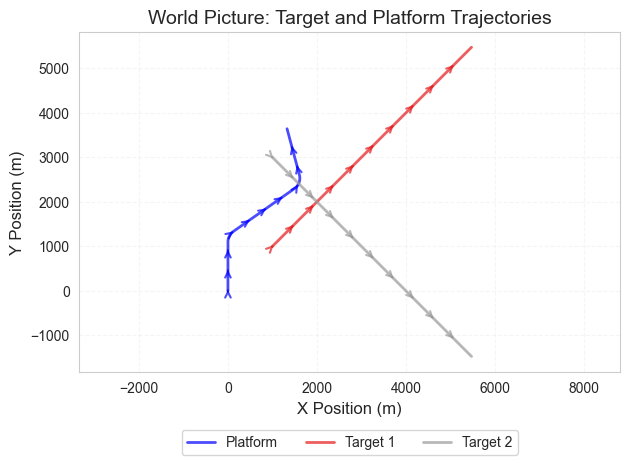

In [52]:
timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]


# Plot 2: Trajectories in Cartesian space
fig2, ax_path = plt.subplots()

# Extract platform positions
platform_x = []
platform_y = []
array_x = []
array_y = []

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])
    
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Plot platform trajectory with direction arrows
ax_path.plot(platform_x, platform_y, 'b-', label='Platform', linewidth=2, alpha=0.7)
# ax_path.plot(array_x, array_y, 'g--', label='Array Center', linewidth=1.5, alpha=0.6)

# Add direction arrows for platform (every 10th point to avoid clutter)
arrow_interval = max(1, len(platform_x) // 10)
for i in range(0, len(platform_x) - 1, arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_path.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                    xytext=(platform_x[i], platform_y[i]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

# Plot target trajectories with different colors
colors = plt.cm.Set1(np.linspace(0, 1, NUM_TARGETS))

for target_idx, target_ground_truth in enumerate(target_ground_truths):
    target_x = [state.state_vector[0] for state in target_ground_truth]
    target_y = [state.state_vector[2] for state in target_ground_truth]
    
    color = colors[target_idx]
    ax_path.plot(target_x, target_y, '-', color=color, 
                label=f'Target {target_idx + 1}', linewidth=2, alpha=0.7)
    
    # Add direction arrows for each target (every 10th point)
    for i in range(0, len(target_x) - 1, arrow_interval):
        dx = target_x[i + 1] - target_x[i]
        dy = target_y[i + 1] - target_y[i]
        ax_path.annotate('', xy=(target_x[i + 1], target_y[i + 1]), 
                        xytext=(target_x[i], target_y[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))

ax_path.set_xlabel('X Position (m)', fontsize=12)
ax_path.set_ylabel('Y Position (m)', fontsize=12)
ax_path.set_title(f'World Picture: Target and Platform Trajectories', fontsize=14)
ax_path.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=4)
ax_path.grid(True, alpha=0.3)
ax_path.axis('equal')
plt.tight_layout()



# RUN SIMULATION WITH DETECTION

In [53]:
# ============================================================================
# RUN SIMULATION WITH DETECTION
# ============================================================================

data_generators = []
for simulator in simulators:
    data_generator = simulator.sensor_data_gen()
    data_generators.append(data_generator)


# Create detection chain
cfar_detector = CFARDetector(
    num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
    num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
    threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
)

detection_chain = [cfar_detector]
if DET_PARAMS["peak_detector"]["distance"] > 0:
    peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])
    detection_chain.append(peak_detector)

detectors = []
for data_generator in data_generators:
    detector = PassiveSonarDetector(
        detection_chain=detection_chain,
        sensor_data_gen=data_generator,
        steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"]
    )
    detectors.append(detector)

# Run detection
print("Running detection chain...")

all_detections_per_bf = []
snr_maps = []
for detector in detectors:
    all_detections = list(detector.detections_gen(progress_bar=True))
    snr_map = detector.snr_history
    all_detections_per_bf.append(all_detections)
    snr_maps.append(snr_map)



Running detection chain...


Generating Detections: 180it [00:38,  4.68it/s]
Generating Detections: 180it [00:23,  7.80it/s]
Generating Detections: 180it [00:25,  7.08it/s]


# VISUALIZATION

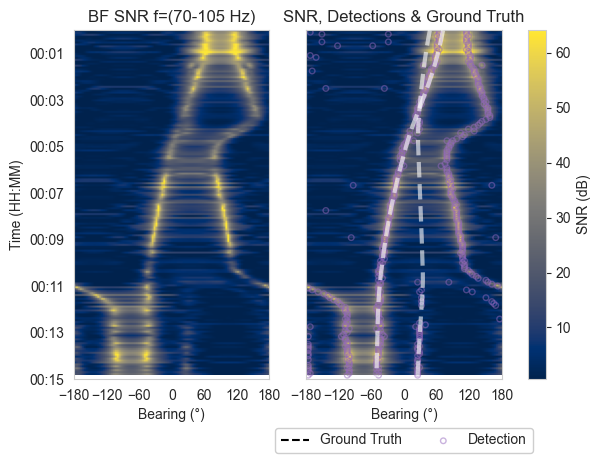

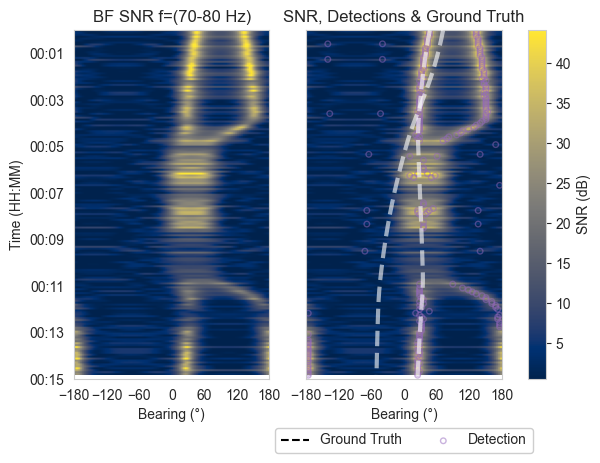

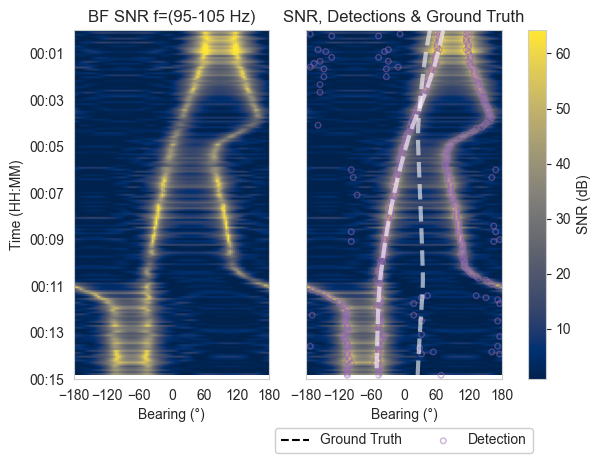

In [54]:
# ============================================================================
# VISUALIZATION
# ============================================================================

for all_detections, snr_map, BF_PARAMS in zip(all_detections_per_bf, snr_maps, BF_PARAMS_LIST):

    timesteps = [
        SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        for i in range(SIM_PARAMS["num_steps"])
    ]

    detections_for_plotter = [detection_set for _, detection_set in all_detections]

    # Plot 1: Beamformer output with detections
    fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

    style_guide = {
        "figure": {
            "figsize": (4, 4),
            "font_size": 10
        }
    }
    plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

    # Left: Raw SNR (exclude last timestep)
    plotter.plot_snr(
        snr_array=snr_map[:-1],
        timesteps=timesteps[:-1],
        all_detections=[],
        truths=[],
        ax=axs[0],
        add_colorbar=False
    )
    axs[0].set_title(f"BF SNR f=({BF_PARAMS['fmin']:.0f}-{BF_PARAMS['fmax']:.0f} Hz)")

    # Right: SNR with detections and truth (exclude last timestep)
    _, im = plotter.plot_snr(
        snr_array=snr_map[:-1],
        timesteps=timesteps[:-1],
        all_detections=detections_for_plotter[:-1],
        truths=relative_bearing_ground_truths,
        ax=axs[1],
        add_colorbar=False
    )
    axs[1].set_ylabel("")
    axs[1].set_title(f"SNR, Detections & Ground Truth")

    # Add shared colorbar
    fig1.colorbar(im, ax=axs.tolist(), label='SNR (dB)')

# plt.suptitle(
#     f"Random Scenario: {NUM_TARGETS} Targets, {ARRAY_PARAMS['num_sensors']} Sensors",
#     fontsize=14,
#     fontweight="bold",
#     y=1.02
# )

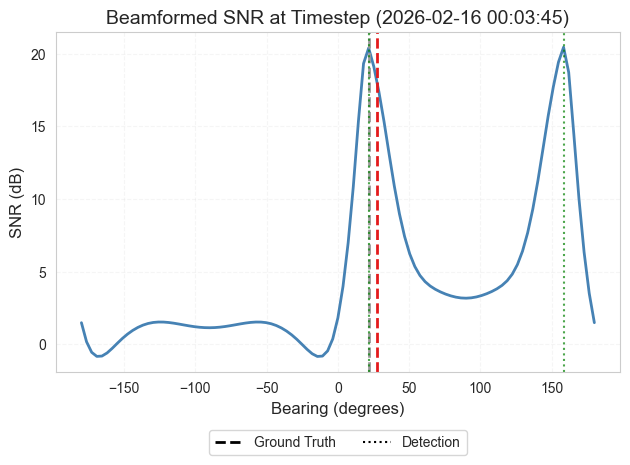

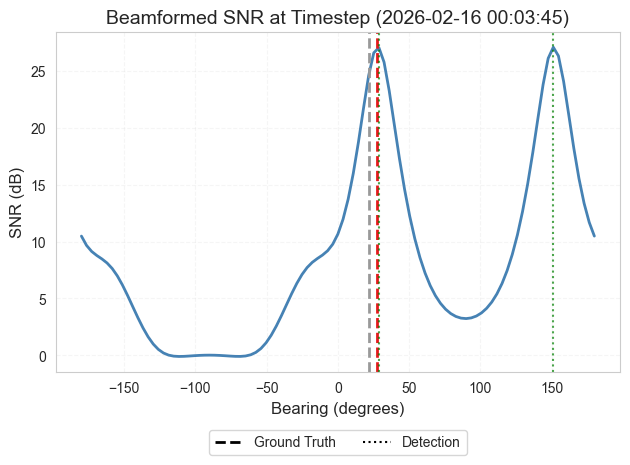

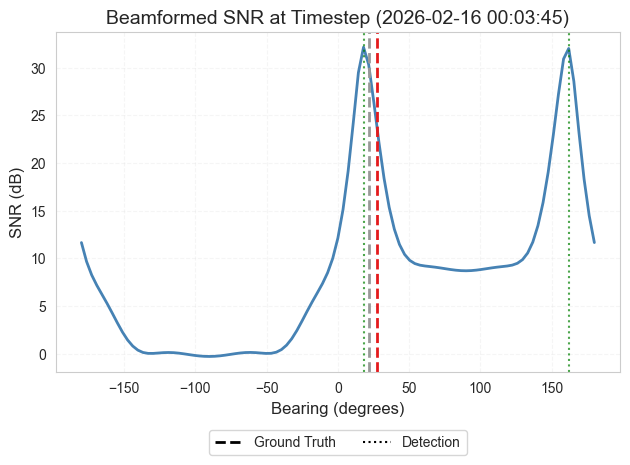

In [55]:
for all_detections, snr_map in zip(all_detections_per_bf, snr_maps):

    timesteps = [
        SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        for i in range(SIM_PARAMS["num_steps"])
    ]

    detections_for_plotter = [detection_set for _, detection_set in all_detections]

    # Plot 3: Beamformed SNR at middle timestep
    fig3, ax_middle = plt.subplots()

    middle_timestep_idx = SIM_PARAMS["num_steps"] // 4
    middle_snr = snr_map[middle_timestep_idx, :]
    middle_time = timesteps[middle_timestep_idx]

    steering_azimuths_deg = np.rad2deg(BF_PARAMS["steering_azimuths_rad"])
    ax_middle.plot(steering_azimuths_deg, middle_snr, linewidth=2, color='steelblue')
    ax_middle.set_xlabel('Bearing (degrees)', fontsize=12)
    ax_middle.set_ylabel('SNR (dB)', fontsize=12)
    ax_middle.set_title(f'Beamformed SNR at Timestep ({middle_time})', fontsize=14)
    ax_middle.grid(True, alpha=0.3)

    # Mark ground truth bearings for all targets
    for target_idx, gt_relative_bearings in enumerate([
        [state.state_vector[0] for state in gt_path.states] 
        for gt_path in relative_bearing_ground_truths
    ]):
        gt_bearing_deg = np.rad2deg(gt_relative_bearings[middle_timestep_idx])
        color = colors[target_idx]
        ax_middle.axvline(gt_bearing_deg, color=color, linestyle='--', linewidth=2, 
                        label=f'Target {target_idx + 1} GT ({gt_bearing_deg:.1f}°)')

    # Mark detections at this timestep if any
    if len(detections_for_plotter[middle_timestep_idx]) > 0:
        for det_idx, det in enumerate(detections_for_plotter[middle_timestep_idx]):
            det_bearing_deg = np.rad2deg(det.state_vector[0])
            label = 'Detections' if det_idx == 0 else None
            ax_middle.axvline(det_bearing_deg, color='green', linestyle=':', linewidth=1.5, 
                            label=label, alpha=0.7)

    # Create custom legend handles
    from matplotlib.lines import Line2D
    custom_handles = [
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Ground Truth'),
        Line2D([0], [0], color='black', linestyle=':', linewidth=1.5, label='Detection')
    ]
    ax_middle.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=2)
    plt.tight_layout()


